In [21]:
import requests
import jieba
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from string import punctuation
import re

In [16]:
url="https://new.qq.com/rain/a/20230921A0A4Y900"
a = requests.get(url)
print(a.text)
wenzhang = a.text

<!DOCTYPE html>
<html lang="zh-CN">

<head>
    <title>华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底_腾讯新闻</title>
<meta name="Description" content="近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4....">
<meta name="baidu-site-verification" content="jJeIJ5X7pP" />
  <script src="//js.aq.qq.com/js/aq_common.js"></script>
    <meta charset="utf-8">
<!--[if lte IE 8]><meta http-equiv="refresh" content="0; url=/upgrade.htm"><![endif]-->
</meta>
<meta http-equiv="X-UA-Compatible" content="IE=Edge" />
<meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no" />
<link rel="shortcut icon" href="https://mat1.gtimg.com/qqcdn/qqindex2021/favicon.ico">
<link rel="dns-prefetch" href="//mat1.gtimg.com">
<link rel="dns-prefetch" href="//imgcache.qq.com">
<link rel="dns-prefetch" href="//pacaio.match.qq.com">
<link rel="dns-prefetch" href="//openapi.inews.qq.com">
<link rel="dns-prefetch" href="//i.news.qq.com">
<link rel="dns-prefetc

limit_output extension: Maximum message size of 10000 exceeded with 18438 characters

In [17]:
t=wenzhang.split("<div class=\"content-article\">")[1]
t=t.split("<div id=\"Status\"></div>")[0]
print(t)


          <h1>华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底</h1>
          <div id="ArticleAuthor"></div>
                    <div id="ArticleContent">
    <p class="one-p">近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4日到9月10日，华为以17%的销量市场份额位列第二，仅落后于荣耀0.2%。预计在9月11日到9月17日，华为有望夺得销量市场份额的第一名。</p>
  <p class="one-p">
    <img class="content-picture" src="//inews.gtimg.com/news_bt/OUmB7Cl5F4caXIVKSy_Im0NqRKi5wKPm-_Y0yojXfDerAAA/1000" />
  </p>
  <p class="one-p">华为Mate 60 Pro的表现出乎意料地好，出货量上调至600万台，增长了20%。据消息称，Mate 60 Pro的加单量已经达到了1500万至1700万台，显示出消费者对该款手机的强烈需求，为华为带来了积极的信号。</p>
  <p class="one-p">
    <img class="content-picture" src="//inews.gtimg.com/news_bt/OxHvCllYuafCZZLULF-we7hzM4lIySTIq3OgOjA94vIWIAA/1000" />
  </p>
  <p class="one-p">华为Mate 60 Pro的突然上市方式给中国顾客带来了惊喜。华为选择了没有提前公布信息的方式，让经销商和消费者都措手不及。这种突然上市的方式让消费者感到新鲜和兴奋，因为他们能够第一时间体验到华为最新的技术和创新。这也展示了华为的灵活性和应对挑战的能力。</p>
  <p class="one-p">
    <img class="content-picture" src="//inews.gtimg.com/news_bt

In [18]:
t=t.replace("<div id=\"ArticleAuthor\">"," ") 
t=t.replace("<div id=\"ArticleContent\">"," ") 
print(t)


          <h1>华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底</h1>
           </div>
                     
    <p class="one-p">近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4日到9月10日，华为以17%的销量市场份额位列第二，仅落后于荣耀0.2%。预计在9月11日到9月17日，华为有望夺得销量市场份额的第一名。</p>
  <p class="one-p">
    <img class="content-picture" src="//inews.gtimg.com/news_bt/OUmB7Cl5F4caXIVKSy_Im0NqRKi5wKPm-_Y0yojXfDerAAA/1000" />
  </p>
  <p class="one-p">华为Mate 60 Pro的表现出乎意料地好，出货量上调至600万台，增长了20%。据消息称，Mate 60 Pro的加单量已经达到了1500万至1700万台，显示出消费者对该款手机的强烈需求，为华为带来了积极的信号。</p>
  <p class="one-p">
    <img class="content-picture" src="//inews.gtimg.com/news_bt/OxHvCllYuafCZZLULF-we7hzM4lIySTIq3OgOjA94vIWIAA/1000" />
  </p>
  <p class="one-p">华为Mate 60 Pro的突然上市方式给中国顾客带来了惊喜。华为选择了没有提前公布信息的方式，让经销商和消费者都措手不及。这种突然上市的方式让消费者感到新鲜和兴奋，因为他们能够第一时间体验到华为最新的技术和创新。这也展示了华为的灵活性和应对挑战的能力。</p>
  <p class="one-p">
    <img class="content-picture" src="//inews.gtimg.com/news_bt/Oz5c0A2nrNPZbqTJIMeZuLfGWI4jjJPQf7xagJA-ctfK4A

In [23]:
t=t.replace("</p>"," ")
t=t.replace("</div>"," ")
t=t.replace("<h1>"," ")
t=t.replace("</h1>"," ")
t=t.replace("<p class=\"one-p\">"," ")
print(t)


           华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底 
            
                     
     近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4日到9月10日，华为以17%的销量市场份额位列第二，仅落后于荣耀0.2%。预计在9月11日到9月17日，华为有望夺得销量市场份额的第一名。 
   
    
   
   华为Mate 60 Pro的表现出乎意料地好，出货量上调至600万台，增长了20%。据消息称，Mate 60 Pro的加单量已经达到了1500万至1700万台，显示出消费者对该款手机的强烈需求，为华为带来了积极的信号。 
   
    
   
   华为Mate 60 Pro的突然上市方式给中国顾客带来了惊喜。华为选择了没有提前公布信息的方式，让经销商和消费者都措手不及。这种突然上市的方式让消费者感到新鲜和兴奋，因为他们能够第一时间体验到华为最新的技术和创新。这也展示了华为的灵活性和应对挑战的能力。 
   
    
   
   华为Mate 60 Pro的上市对中国芯片产业来说是一个重要的里程碑。美国的技术封锁给中国芯片产业带来了巨大的压力。然而，华为Mate 60 Pro的上市代表着中国芯片产业在自主创新和技术突破方面取得了重要的进展。华为在Mate 60 Pro中采用了自主研发的麒麟9000系列芯片，显示出中国芯片产业在高端技术领域的实力。这对中国消费者来说是一个好消息，同时也对美国技术霸权构成了一定的挑战。 
   
    
   
   尽管华为Mate 60 Pro+的上市并没有像前者那样引起同样的热烈反应，销售情况相对较差，可能是因为消费者对华为新机型的需求已经在Mate 60 Pro上得到了满足，或者是其他因素导致市场反应不如预期。不过，华为Mate 60 Pro+的上市仍然标志着华为向国际市场迈出了重要的一步，重新开始争夺海外市场份额。华为将继续努力提升产品的竞争力，以吸引更多的消费者。 
   
    
   
   华为Mate 60 Pro在市场上取得了令人瞩目的销售成绩，备受消费者青睐。这

In [24]:
pattern = r'<img .*?/>'
t = re.sub(pattern, '', t)
print(t)


           华为Mate60系列拿下中国智能手机市场第二，其中Pro+销量或将垫底 
            
                     
     近期，华为发布了备受关注的Mate 60 / Pro/Pro+系列和Mate X5折叠屏手机，引发了国内智能手机市场的一波抢购热潮。根据供应链数据显示，华为在中国智能手机市场的份额逐渐增加。从9月4日到9月10日，华为以17%的销量市场份额位列第二，仅落后于荣耀0.2%。预计在9月11日到9月17日，华为有望夺得销量市场份额的第一名。 
   
    
   
   华为Mate 60 Pro的表现出乎意料地好，出货量上调至600万台，增长了20%。据消息称，Mate 60 Pro的加单量已经达到了1500万至1700万台，显示出消费者对该款手机的强烈需求，为华为带来了积极的信号。 
   
    
   
   华为Mate 60 Pro的突然上市方式给中国顾客带来了惊喜。华为选择了没有提前公布信息的方式，让经销商和消费者都措手不及。这种突然上市的方式让消费者感到新鲜和兴奋，因为他们能够第一时间体验到华为最新的技术和创新。这也展示了华为的灵活性和应对挑战的能力。 
   
    
   
   华为Mate 60 Pro的上市对中国芯片产业来说是一个重要的里程碑。美国的技术封锁给中国芯片产业带来了巨大的压力。然而，华为Mate 60 Pro的上市代表着中国芯片产业在自主创新和技术突破方面取得了重要的进展。华为在Mate 60 Pro中采用了自主研发的麒麟9000系列芯片，显示出中国芯片产业在高端技术领域的实力。这对中国消费者来说是一个好消息，同时也对美国技术霸权构成了一定的挑战。 
   
    
   
   尽管华为Mate 60 Pro+的上市并没有像前者那样引起同样的热烈反应，销售情况相对较差，可能是因为消费者对华为新机型的需求已经在Mate 60 Pro上得到了满足，或者是其他因素导致市场反应不如预期。不过，华为Mate 60 Pro+的上市仍然标志着华为向国际市场迈出了重要的一步，重新开始争夺海外市场份额。华为将继续努力提升产品的竞争力，以吸引更多的消费者。 
   
    
   
   华为Mate 60 Pro在市场上取得了令人瞩目的销售成绩，备受消费者青睐。这

In [25]:
p = '“”：‘’{}？！()、%^>℃:.""--——=&#@*<!；（）《》，。、【】'
p = p + punctuation

In [26]:
i=[ ]
if True:
    words = jieba.cut(t,cut_all=True) 
    for s in words :
        if s.strip() in p:
            pass
        else:
            i.append(s.strip())
print(i)

['华为', 'Mate60', '系列', '拿下', '中国', '智能', '智能手机', '能手', '手机', '市场', '第二', '其中', 'Pro', '销量', '或', '将', '垫底', '近期', '华为', '发布', '了', '备受', '关注', '的', 'Mate', '60', 'Pro', 'Pro', '系列', '和', 'Mate', 'X5', '折叠', '屏', '手机', '引发', '了', '国内', '智能', '智能手机', '能手', '手机', '市场', '的', '一', '波', '抢购', '热潮', '根据', '供应', '供应链', '数据', '显示', '华为', '在', '中国', '智能', '智能手机', '能手', '手机', '市场', '的', '份额', '逐渐', '渐增', '增加', '从', '9', '月', '4', '日', '到', '9', '月', '10', '日', '华为', '以', '17', '的', '销量', '市场', '市场份额', '份额', '位列', '第二', '仅', '落后', '于', '荣耀', '0', '2', '预计', '在', '9', '月', '11', '日', '到', '9', '月', '17', '日', '华为', '有望', '夺得', '销量', '市场', '市场份额', '份额', '的', '第一', '第一名', '一名', '华为', 'Mate', '60', 'Pro', '的', '表现', '现出', '出乎', '出乎意料', '意料', '地', '好', '出货', '出货量', '上调', '调至', '600', '万台', '增长', '了', '20', '据', '消息', '称', 'Mate', '60', 'Pro', '的', '加', '单', '量', '已经', '达到', '了', '1500', '万', '至', '1700', '万台', '显示', '出', '消费', '消费者', '对', '该款', '手机', '的', '强烈', '需求', '为', '华为', '带来', '了', '积极', '的', '信

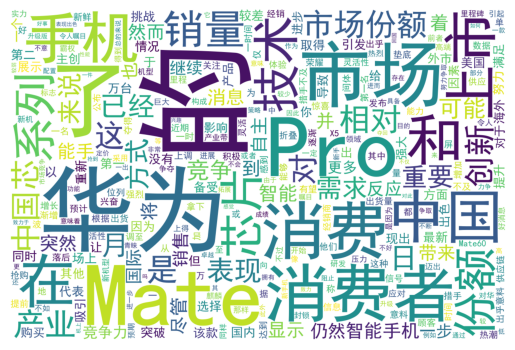

In [27]:
b = WordCloud(
    max_font_size=300,
    min_font_size=10,
    max_words=500,
    font_path='simhei.ttf',
    background_color= "white",
    width=1200,
    height=800,
    collocations=False,
    font_step=1
)
s=b.generate( ' '.join(i))
plt.imshow( s)
plt.axis('off')
plt.show()